# Agent Security Risk Analysis — Model Triangulation Pipeline

Four models, each answering a distinct security question about `action_risk_score`:

| # | Model | Question |
|---|-------|----------|
| 1 | XGBoost + SHAP | What drives the risk score? |
| 2 | Shallow decision tree | Can the scoring logic be expressed as human-readable rules? |
| 3 | Isolation Forest | Are there anomalous requests the score under-rates (blind spots)? |
| 4 | Logistic regression | Do access decisions follow the risk score consistently? |

**Leakage note:** `human_approval_required` (corr ≈ 0.73) and `access_decision` are downstream of the score, so they are excluded from models predicting it.

## About this notebook

### What problem is this solving?
An automated agent assigns every incoming request an `action_risk_score` (0–100)
and an `access_decision` (e.g. Allowed / Blocked / Escalated). We did **not**
build that scoring system — we are *auditing* it. The goal is to understand,
stress-test, and find weaknesses in a scoring model that is already in production.

### Why four models instead of one? (Triangulation)
No single model answers every question about a black-box score. Each of the four
models below is chosen to answer **one specific question**, and the value comes
from **reading them together** — where they agree we gain confidence, where they
disagree we've found something worth investigating.

| Model | Type | What it tells us |
|-------|------|------------------|
| XGBoost + SHAP | Accurate but complex regressor | The *true* drivers of the score, ranked by impact |
| Decision tree (depth 3) | Deliberately simple regressor | Whether those drivers form simple, legible rules |
| Isolation Forest | Unsupervised anomaly detector | Unusual requests the score may have under-rated |
| Logistic regression | Interpretable classifier | Whether real access decisions track the score |

### The single most important idea: data leakage
`action_risk_score` causes downstream fields. In particular:
  - `human_approval_required` is triggered *because* a score is high.
  - `access_decision` is made *using* the score.

If we let a model that predicts the score see those columns, it would "cheat" —
learning the effect instead of the cause and giving us a useless, over-optimistic
result. So Models 1–3 **exclude** these leaky columns. (Model 4 is the exception:
it deliberately *uses* the score as an input, because its question is precisely
"do decisions follow the score?")

### How to run it
Run the cells top to bottom. It expects `agent_security_risk_scores.csv` in the
same folder. Dependencies: `pandas`, `numpy`, `matplotlib`, `scikit-learn`,
`xgboost`, and `shap`. Read the **Triangulated findings** section at the bottom
to interpret the combined output.

In [1]:
# --- Core data / plotting stack ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Model selection & metrics ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, classification_report

# --- The four model families used below ---
from sklearn.tree import DecisionTreeRegressor, export_text  # Model 2 (interpretable rules)
from sklearn.ensemble import IsolationForest                 # Model 3 (anomaly detection)
from sklearn.linear_model import LogisticRegression          # Model 4 (decision consistency)
from sklearn.preprocessing import StandardScaler             # scales features for the linear model
import xgboost as xgb                                        # Model 1 (accurate regressor)
import shap                                                  # explains Model 1's predictions

# Fixed seed everywhere -> reproducible splits, models, and anomaly flags.
RANDOM_STATE = 42

# --- Load the dataset directly from Kaggle (no manual file needed) ---
import os, glob

DATASET = "algozee/agentic-ai-security-risk-dataset"

# 1) If you added the dataset via the "Add Input" panel (right sidebar),
#    Kaggle mounts it under /kaggle/input/... -> search there first. Works offline.
csv_paths = glob.glob("/kaggle/input/**/*.csv", recursive=True)

# 2) Otherwise pull it programmatically with kagglehub
#    (requires Internet = ON in the notebook Settings sidebar).
if not csv_paths:
    import kagglehub
    dl_dir = kagglehub.dataset_download(DATASET)
    csv_paths = glob.glob(os.path.join(dl_dir, "**", "*.csv"), recursive=True)

assert csv_paths, ("No CSV found. Either add the dataset via 'Add Input', or "
                   "enable Internet in Settings so kagglehub can download it.")

CSV_PATH = csv_paths[0]           # first CSV in the dataset
print("Loading:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print(df.shape)   # (rows, columns) sanity check
df.head()         # eyeball the first few rows / column names

Loading: /kaggle/input/datasets/algozee/agentic-ai-security-risk-dataset/agent_security_risk_scores.csv
(2200, 15)


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
0,customer_support_agent,4,admin,read_record,file_storage_api,api_key_secret,5,0,64,0,83,0,0,1,Blocked
1,customer_support_agent,2,analyst,export_report,crm_api,sales_pipeline,3,0,66,0,65,1,2,1,Blocked
2,hr_onboarding_agent,3,vendor,change_permission,external_webhook,sales_pipeline,3,0,100,0,51,1,2,1,Blocked
3,hr_onboarding_agent,2,manager,send_email,hris_api,customer_profile,3,0,64,0,64,0,0,1,Blocked
4,finance_reconciliation_agent,1,vendor,read_record,database_api,source_code_repo,4,0,41,0,63,0,1,1,Blocked


## 0. Quick EDA

Before modeling, look at the target's distribution, the decision balance, and
which numeric features move with the score. This is also where the leakage of
`human_approval_required` becomes visible as an unusually high correlation.

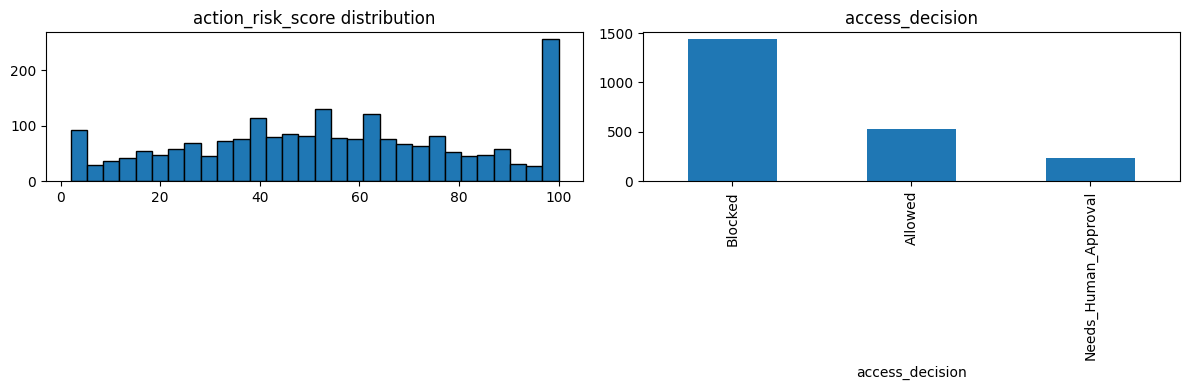

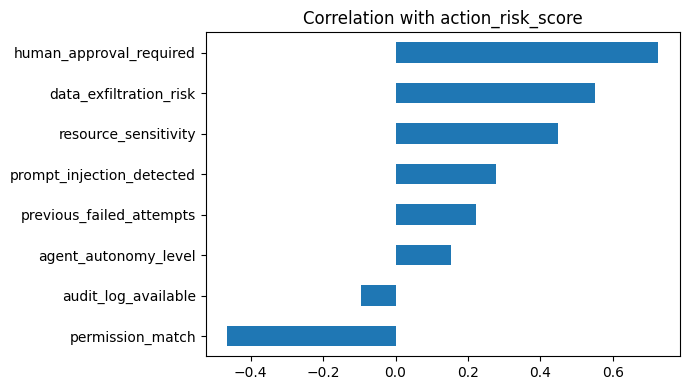

In [2]:
# Two quick diagnostic plots side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: how risk scores are distributed across all requests (skew? clusters? gaps?).
axes[0].hist(df["action_risk_score"], bins=30, edgecolor="k")
axes[0].set_title("action_risk_score distribution")

# Right: class balance of the access decision (are Blocked cases rare?).
df["access_decision"].value_counts().plot.bar(ax=axes[1], title="access_decision")
plt.tight_layout(); plt.show()

# Correlation of every numeric feature with the score, sorted for readability.
# NOTE: a very high value here (e.g. human_approval_required ~0.73) is a red flag
# for leakage — that column is an *effect* of the score, not a driver of it.
corr = df.select_dtypes("number").corr()["action_risk_score"].drop("action_risk_score").sort_values()
corr.plot.barh(figsize=(7, 4), title="Correlation with action_risk_score")
plt.tight_layout(); plt.show()

## Preprocessing

One-hot encode categoricals. Feature set for score models excludes the leaky columns.

In [3]:
TARGET = "action_risk_score"                       # what Models 1-3 predict
LEAKY = ["human_approval_required", "access_decision"]  # downstream of the score -> drop
cat_cols = ["agent_role", "user_role", "requested_action", "tool_requested", "resource_type"]

# Build the feature matrix X:
#   - drop the target and the leaky columns
#   - one-hot encode the categoricals. drop_first=False keeps EVERY category as its
#     own column, which makes SHAP attributions easier to read (one bar per category).
X = pd.get_dummies(df.drop(columns=[TARGET] + LEAKY), columns=cat_cols, drop_first=False)
y = df[TARGET]

# Hold out 25% of rows to measure how well each model generalizes to unseen requests.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
print(f"{X.shape[1]} features, train={len(X_train)}, test={len(X_test)}")

67 features, train=1650, test=550


## 1. XGBoost + SHAP — what drives the score?

In [4]:
# Gradient-boosted trees: accurate and able to capture feature interactions.
# Hyperparameters chosen to resist overfitting:
#   max_depth=4       -> shallow trees, limited interaction complexity
#   learning_rate=0.05 with n_estimators=400 -> many small, cautious steps
#   subsample / colsample_bytree=0.9 -> each tree sees 90% of rows/cols (regularization)
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)
pred = xgb_model.predict(X_test)

# R2: fraction of score variance explained (1.0 = perfect).
# MAE: average miss in actual score points -> directly interpretable on the 0-100 scale.
print(f"R2  = {r2_score(y_test, pred):.3f}")
print(f"MAE = {mean_absolute_error(y_test, pred):.2f} points (score range 0-100)")

R2  = 0.937
MAE = 5.45 points (score range 0-100)


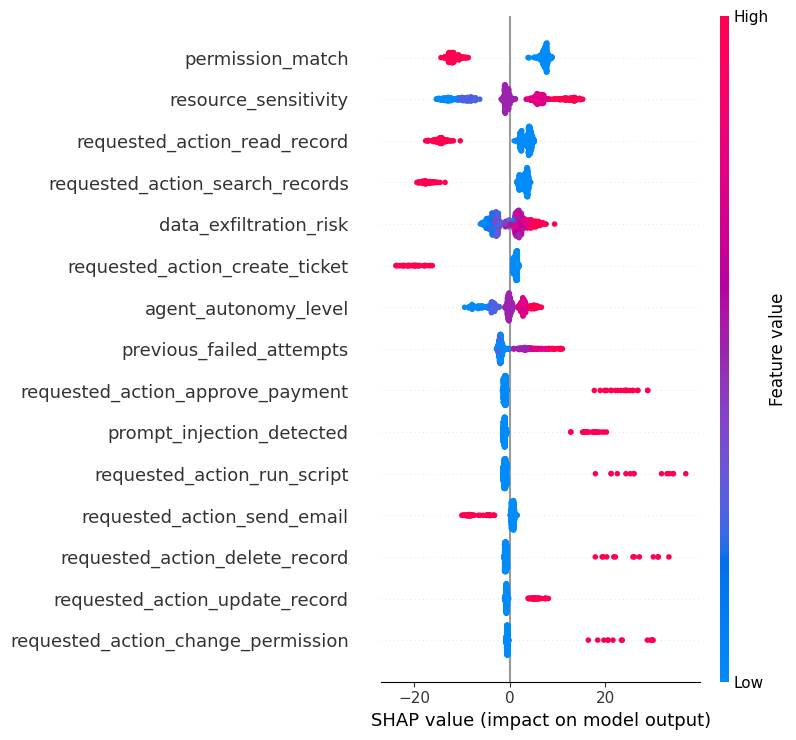

In [5]:
# SHAP explains the trained model: how much, and in which direction, each feature
# pushes each individual prediction away from the baseline.
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot: features ranked by importance; color shows feature value,
# horizontal spread shows the effect on the predicted score.
shap.summary_plot(shap_values, X_test, max_display=15)

In [6]:
# Collapse the per-row SHAP matrix into one number per feature:
# mean absolute SHAP = average impact on the score, measured in score points.
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
top_drivers = mean_abs.sort_values(ascending=False).head(10)
print("Top 10 drivers (mean |SHAP|, in score points):")
print(top_drivers.round(2))   # <- treat this ranking as ground truth for later comparison

Top 10 drivers (mean |SHAP|, in score points):
permission_match                    9.13
resource_sensitivity                6.22
requested_action_read_record        5.62
requested_action_search_records     5.25
data_exfiltration_risk              2.92
requested_action_create_ticket      2.65
agent_autonomy_level                2.64
previous_failed_attempts            2.62
requested_action_approve_payment    1.94
prompt_injection_detected           1.89
dtype: float32


## 2. Shallow decision tree — extract the scoring rules

A depth-3 tree fit to the same target. If its splits agree with SHAP's top drivers, the scoring logic is coherent.

In [7]:
# A deliberately tiny tree so the whole thing is human-readable:
#   max_depth=3        -> at most 3 questions from root to leaf
#   min_samples_leaf=50 -> no leaf built on fewer than 50 requests (avoids noise rules)
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# A lower R2 than XGBoost is EXPECTED and fine — this model is for legibility,
# not accuracy. export_text prints the tree as plain if/else rules.
print(f"Tree R2 (test) = {r2_score(y_test, tree.predict(X_test)):.3f}\n")
print(export_text(tree, feature_names=list(X.columns), decimals=1))
# Interpretation: do the split variables match SHAP's top drivers?
#   agree    -> scoring logic is simple and consistent
#   disagree -> the score leans on interactions that plain rules can't capture

Tree R2 (test) = 0.397

|--- data_exfiltration_risk <= 50.5
|   |--- permission_match <= 0.5
|   |   |--- requested_action_read_record <= 0.5
|   |   |   |--- value: [58.9]
|   |   |--- requested_action_read_record >  0.5
|   |   |   |--- value: [35.8]
|   |--- permission_match >  0.5
|   |   |--- requested_action_read_record <= 0.5
|   |   |   |--- value: [37.1]
|   |   |--- requested_action_read_record >  0.5
|   |   |   |--- value: [17.1]
|--- data_exfiltration_risk >  50.5
|   |--- permission_match <= 0.5
|   |   |--- prompt_injection_detected <= 0.5
|   |   |   |--- value: [69.2]
|   |   |--- prompt_injection_detected >  0.5
|   |   |   |--- value: [92.8]
|   |--- permission_match >  0.5
|   |   |--- data_exfiltration_risk <= 70.5
|   |   |   |--- value: [47.1]
|   |   |--- data_exfiltration_risk >  70.5
|   |   |   |--- value: [61.4]



## 3. Isolation Forest — blind spots

Fit on features only (score excluded). Anomalous requests that nevertheless received a **low** risk score are potential gaps in the scoring system.

In [8]:
# Unsupervised anomaly detector. contamination=0.05 tells it to flag the ~5%
# most unusual requests. It never sees the score, so anomalies are defined purely
# by how unusual a request's FEATURES are.
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE)
anomaly = iso.fit_predict(X) == -1   # sklearn returns -1 for anomalies, 1 for normal
df_a = df.assign(anomaly=anomaly)    # attach the flag back to the original dataframe

print(f"Flagged {anomaly.sum()} anomalous requests ({anomaly.mean():.1%})")
# If anomalies score about the same as normal rows, the score isn't reacting to
# their strangeness — a warning sign in itself.
print(f"Mean score  — anomalies: {df_a.loc[anomaly, TARGET].mean():.1f}  vs normal: {df_a.loc[~anomaly, TARGET].mean():.1f}")

# BLIND SPOTS = structurally unusual requests that still got a LOW score (<40).
# These are the dangerous gaps: weird requests the scoring system waved through.
blind_spots = df_a[anomaly & (df_a[TARGET] < 40)]
print(f"\nPotential blind spots (anomalous but score < 40): {len(blind_spots)}")
blind_spots.sort_values(TARGET).head(10)

Flagged 110 anomalous requests (5.0%)
Mean score  — anomalies: 84.1  vs normal: 53.3

Potential blind spots (anomalous but score < 40): 4


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision,anomaly
1756,data_analytics_agent,1,service_account,create_ticket,finance_erp_api,support_ticket,1,1,2,0,18,0,0,0,Allowed,True
156,it_helpdesk_agent,1,contractor,download_file,database_api,support_ticket,2,1,25,0,47,0,0,0,Allowed,True
1455,legal_contract_agent,2,admin,export_report,email_api,public_knowledge_base,1,1,31,0,44,0,0,0,Allowed,True
1998,procurement_agent,2,employee,search_records,finance_erp_api,public_knowledge_base,1,0,36,0,27,0,5,0,Blocked,True


In [9]:
# Profile the blind spots: what do these under-scored anomalies have in common?
# Recurring actions / resources / roles here point to concrete scoring-policy gaps.
if len(blind_spots):
    for col in ["requested_action", "resource_type", "user_role", "access_decision"]:
        print(f"\n{col}:")
        print(blind_spots[col].value_counts().head(5).to_string())


requested_action:
requested_action
download_file     1
export_report     1
create_ticket     1
search_records    1

resource_type:
resource_type
support_ticket           2
public_knowledge_base    2

user_role:
user_role
contractor         1
admin              1
service_account    1
employee           1

access_decision:
access_decision
Allowed    3
Blocked    1


## 4. Logistic regression — are decisions consistent with the score?

Multinomial logistic on `access_decision`. Then flag contradictions: high-score requests that were **Allowed** and low-score requests that were **Blocked**.

In [10]:
# Model 4's question is "do decisions follow the score?", so unlike Models 1-3
# it INTENTIONALLY keeps action_risk_score as a feature. We still drop access_decision
# (that's the target) and human_approval_required (leaky w.r.t. the decision).
X_dec = pd.get_dummies(df.drop(columns=["access_decision", "human_approval_required"]), columns=cat_cols)
y_dec = df["access_decision"]

# Logistic regression is sensitive to feature scale, so standardize to mean 0 / std 1.
scaler = StandardScaler()
X_dec_s = scaler.fit_transform(X_dec)

# stratify=y_dec keeps the decision-class proportions identical in train and test,
# which matters when some decisions (e.g. Blocked) are rare.
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_dec_s, y_dec, test_size=0.25,
                                              random_state=RANDOM_STATE, stratify=y_dec)

# max_iter bumped to 2000 so the solver fully converges on the wide one-hot matrix.
logit = LogisticRegression(max_iter=2000, C=1.0)
logit.fit(Xd_tr, yd_tr)

# Precision/recall/F1 per decision class. High scores mean decisions are highly
# predictable from the features + score (i.e. the policy is consistent).
print(classification_report(yd_te, logit.predict(Xd_te)))

                      precision    recall  f1-score   support

             Allowed       0.96      0.91      0.93       131
             Blocked       0.99      0.99      0.99       359
Needs_Human_Approval       0.75      0.85      0.80        60

            accuracy                           0.95       550
           macro avg       0.90      0.91      0.91       550
        weighted avg       0.96      0.95      0.95       550



In [11]:
# One coefficient column per decision class. Positive = pushes toward that decision,
# negative = pushes away. Sorting by absolute value surfaces the strongest signals.
coefs = pd.DataFrame(logit.coef_.T, index=X_dec.columns, columns=logit.classes_)
print("Strongest coefficients per decision class:\n")
for cls in logit.classes_:
    print(f"--- {cls} ---")
    print(coefs[cls].sort_values(key=abs, ascending=False).head(6).round(2).to_string(), "\n")

Strongest coefficients per decision class:

--- Allowed ---
permission_match                    2.93
action_risk_score                  -2.21
data_exfiltration_risk             -1.47
prompt_injection_detected          -0.82
requested_action_approve_payment   -0.73
requested_action_run_script        -0.71 

--- Blocked ---
permission_match                   -4.39
action_risk_score                   1.96
data_exfiltration_risk              1.63
prompt_injection_detected           1.37
requested_action_run_script         0.87
requested_action_approve_payment    0.69 

--- Needs_Human_Approval ---
permission_match                   1.46
prompt_injection_detected         -0.55
resource_type_api_key_secret       0.33
resource_type_access_policy        0.32
action_risk_score                  0.25
requested_action_search_records   -0.24 



In [12]:
# CONTRADICTIONS: cases where enforcement disagrees with the score.
#   allowed_high -> high risk (>=70) yet Allowed  = potential security exceptions
#   blocked_low  -> low risk (<=30) yet Blocked   = possible over-blocking / friction
allowed_high = df[(df.access_decision == "Allowed") & (df[TARGET] >= 70)]
blocked_low = df[(df.access_decision == "Blocked") & (df[TARGET] <= 30)]
print(f"Contradictions:")
print(f"  Allowed despite score >= 70 : {len(allowed_high)}")
print(f"  Blocked despite score <= 30 : {len(blocked_low)}")
allowed_high.head(10)   # each row here is worth a manual audit

Contradictions:
  Allowed despite score >= 70 : 0
  Blocked despite score <= 30 : 98


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision


## 5. Answering the research question directly

> **Can we predict the security risk score of an AI agent's action based on its
> autonomy level, permissions, requested tools, and resource access patterns?
> And can we decide whether an agent should be granted access based on that score?**

The models above give us the ingredients; this section combines them into a
pointed, two-part answer with an explicit verdict for each half.

- **Part A — predictability:** train on *only* the four factor families named in
  the question and measure how much of the risk score they explain.
- **Part B — actionability:** use the risk score *by itself* to predict the real
  `access_decision`, and quantify how much of the decision the score recovers.

In [13]:
# --- Part A: is the score predictable from the four NAMED factor groups? ---
# The question names four factor families. Map each to its one-hot columns by keyword
# so this stays robust to exact column names. Tweak the keywords if your schema differs.
feature_groups = {
    "autonomy level":  [c for c in X.columns if "autonomy" in c.lower()],
    "permissions":     [c for c in X.columns if "permission" in c.lower() or "permit" in c.lower()],
    "requested tools": [c for c in X.columns if "tool" in c.lower() or "api" in c.lower()],
    "resource access": [c for c in X.columns if "resource" in c.lower()],
}
named_cols = sorted({c for cols in feature_groups.values() for c in cols})
for name, cols in feature_groups.items():
    print(f"{name:16s}: {len(cols):>3} columns")
print(f"\nUsing {len(named_cols)} of {X.shape[1]} features (only the four named factors)")

# Guard: if the keywords matched nothing, fall back to all features so the cell still runs.
if not named_cols:
    print("WARNING: no columns matched the keywords — falling back to all features.")
    named_cols = list(X.columns)

# Train the SAME XGBoost recipe on only those factors, then compare to the full model.
xgb_named = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
)
xgb_named.fit(X_train[named_cols], y_train)
pred_named = xgb_named.predict(X_test[named_cols])
r2_named  = r2_score(y_test, pred_named)
mae_named = mean_absolute_error(y_test, pred_named)
r2_full   = r2_score(y_test, xgb_model.predict(X_test))   # reuse Model 1 (all features)

print(f"\nNamed factors only : R2 = {r2_named:.3f} | MAE = {mae_named:.2f} pts (0-100 scale)")
print(f"All features (M1)  : R2 = {r2_full:.3f}")

# Turn the R2 into a plain-language verdict.
verdict_a = ("YES - strongly predictable"        if r2_named >= 0.70 else
             "PARTIALLY - moderately predictable" if r2_named >= 0.40 else
             "NO - only weakly predictable")
print(f"\nPart A verdict: {verdict_a} from the four named factors (R2 = {r2_named:.3f}).")

autonomy level  :   1 columns
permissions     :   2 columns
requested tools :  13 columns
resource access :  16 columns

Using 31 of 67 features (only the four named factors)

Named factors only : R2 = 0.481 | MAE = 16.84 pts (0-100 scale)
All features (M1)  : R2 = 0.937

Part A verdict: PARTIALLY - moderately predictable from the four named factors (R2 = 0.481).


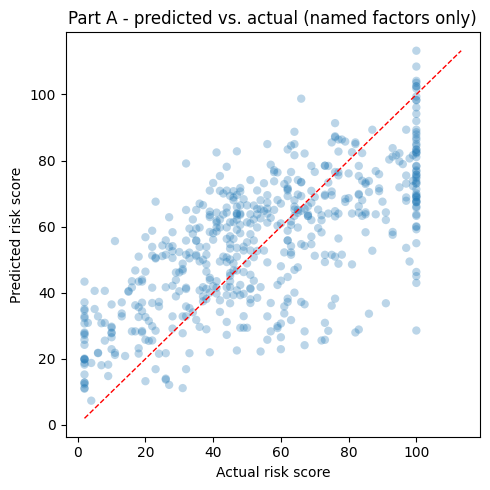

In [14]:
# Visual check for Part A: predicted vs. actual score. Points hug the diagonal = good.
plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred_named, alpha=0.3, edgecolor="none")
lims = [min(y_test.min(), pred_named.min()), max(y_test.max(), pred_named.max())]
plt.plot(lims, lims, "r--", linewidth=1)              # perfect-prediction reference line
plt.xlabel("Actual risk score"); plt.ylabel("Predicted risk score")
plt.title("Part A - predicted vs. actual (named factors only)")
plt.tight_layout(); plt.show()

In [15]:
# --- Part B: can the risk SCORE ALONE decide access? ---
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# First, does the score even separate the decision classes? Compare distributions.
print("Risk score by access_decision:")
print(df.groupby("access_decision")[TARGET].agg(["mean", "median", "count"]).round(1), "\n")

# A classifier that sees ONLY the risk score (one feature) -> predict access_decision.
Xs = df[[TARGET]].values
ys = df["access_decision"]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.25, random_state=RANDOM_STATE, stratify=ys)
score_only = LogisticRegression(max_iter=1000)
score_only.fit(Xs_tr, ys_tr)
pred_so = score_only.predict(Xs_te)

acc_so = accuracy_score(ys_te, pred_so)
f1_so  = f1_score(ys_te, pred_so, average="macro", zero_division=0)
print(classification_report(ys_te, pred_so, zero_division=0))
print(f"Score-only classifier -> accuracy {acc_so:.3f}, macro-F1 {f1_so:.3f}")

Risk score by access_decision:
                      mean  median  count
access_decision                          
Allowed               24.0    22.0    526
Blocked               66.2    65.0   1435
Needs_Human_Approval  54.2    58.0    239 

                      precision    recall  f1-score   support

             Allowed       0.73      0.66      0.69       131
             Blocked       0.77      0.92      0.84       359
Needs_Human_Approval       0.00      0.00      0.00        60

            accuracy                           0.76       550
           macro avg       0.50      0.53      0.51       550
        weighted avg       0.67      0.76      0.71       550

Score-only classifier -> accuracy 0.758, macro-F1 0.509


In [16]:
# How much does the score ALONE recover vs. using EVERY feature (Model 4)?
acc_full = accuracy_score(yd_te, logit.predict(Xd_te))   # reuse Model 4's fitted logit
print(f"Score alone         : accuracy {acc_so:.3f}")
print(f"All features (M4)   : accuracy {acc_full:.3f}")
share = acc_so / acc_full if acc_full else float("nan")
print(f"-> the score alone recovers {share:.0%} of the full-feature accuracy.\n")

verdict_b = ("YES - the score alone is a strong basis for access decisions"        if acc_so >= 0.85 else
             "PARTIALLY - the score helps but misses cases the full model catches" if acc_so >= 0.60 else
             "NO - the score alone is not a reliable basis for access")
print(f"Part B verdict: {verdict_b} (accuracy {acc_so:.3f}).")

# Confusion matrix for the score-only decision model (where does it go wrong?).
labels = sorted(ys.unique())
cm = confusion_matrix(ys_te, pred_so, labels=labels)
print("\nConfusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))

Score alone         : accuracy 0.758
All features (M4)   : accuracy 0.953
-> the score alone recovers 80% of the full-feature accuracy.

Part B verdict: PARTIALLY - the score helps but misses cases the full model catches (accuracy 0.758).

Confusion matrix (rows = actual, cols = predicted):
                      Allowed  Blocked  Needs_Human_Approval
Allowed                    86       45                     0
Blocked                    28      331                     0
Needs_Human_Approval        4       56                     0


## 6. Robustness, baselines & deeper analysis

Before drawing conclusions, we stress-test the results: add a baseline and
cross-validation (so the headline numbers come with error bars), audit for
secondary leakage, handle class imbalance, and dig into the two findings that
matter most — why the score can't decide the *human-approval* tier, and what the
over-blocked cases look like.

In [17]:
# --- 6.1 Baseline + cross-validation: are the score-model numbers trustworthy? ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Baseline: a plain linear model on the same features. XGBoost should beat it,
# and by how much tells us how much the nonlinearity/interactions actually matter.
lin = LinearRegression().fit(X_train, y_train)
print(f"Linear baseline R2 (test) = {r2_score(y_test, lin.predict(X_test)):.3f}")
print(f"XGBoost         R2 (test) = {r2_score(y_test, xgb_model.predict(X_test)):.3f}")

# 5-fold CV so the headline R2 is a mean +/- std, not one lucky split.
cv_xgb = cross_val_score(
    xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                     subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE),
    X, y, cv=5, scoring="r2")
cv_lin = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(f"\n5-fold CV R2 -- XGBoost: {cv_xgb.mean():.3f} +/- {cv_xgb.std():.3f}")
print(f"5-fold CV R2 -- Linear : {cv_lin.mean():.3f} +/- {cv_lin.std():.3f}")

Linear baseline R2 (test) = 0.921
XGBoost         R2 (test) = 0.937

5-fold CV R2 -- XGBoost: 0.936 +/- 0.004
5-fold CV R2 -- Linear : 0.915 +/- 0.008


In [18]:
# --- 6.2 Secondary-leakage check: are the 'threat' signals independent inputs? ---
# data_exfiltration_risk / prompt_injection / previous_failed_attempts are strong
# drivers. Confirm they aren't just the score in disguise (co-derived), the way
# human_approval_required was.
suspects = ["data_exfiltration_risk", "prompt_injection_detected", "previous_failed_attempts"]
present = [c for c in suspects if c in df.columns]
print("Correlation with action_risk_score:")
print(df[present + [TARGET]].corr()[TARGET].drop(TARGET).round(3), "\n")

# Refit XGBoost WITHOUT them. A big R2 drop means they're major (legitimate) drivers;
# an R2 that stays near-perfect using ONLY them would be the red flag for leakage.
drop_cols = [c for c in present if c in X.columns]
m_no_threat = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE)
m_no_threat.fit(X_train.drop(columns=drop_cols), y_train)
print(f"R2 with threat signals    : {r2_score(y_test, xgb_model.predict(X_test)):.3f}")
print(f"R2 without threat signals : {r2_score(y_test, m_no_threat.predict(X_test.drop(columns=drop_cols))):.3f}")

Correlation with action_risk_score:
data_exfiltration_risk       0.550
prompt_injection_detected    0.277
previous_failed_attempts     0.222
Name: action_risk_score, dtype: float64 

R2 with threat signals    : 0.937
R2 without threat signals : 0.879


In [19]:
# --- 6.3 Class-imbalance handling: stop 'Blocked' from dominating Model 4 ---
# Blocked hugely outnumbers Needs_Human_Approval. class_weight='balanced' up-weights
# the rare classes so the model isn't rewarded for just predicting the majority.
logit_bal = LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced")
logit_bal.fit(Xd_tr, yd_tr)
print("Balanced logistic -- access_decision (compare recall on the rare classes vs Model 4):")
print(classification_report(yd_te, logit_bal.predict(Xd_te), zero_division=0))

Balanced logistic -- access_decision (compare recall on the rare classes vs Model 4):
                      precision    recall  f1-score   support

             Allowed       0.97      0.81      0.88       131
             Blocked       0.99      0.98      0.98       359
Needs_Human_Approval       0.62      0.88      0.73        60

            accuracy                           0.93       550
           macro avg       0.86      0.89      0.86       550
        weighted avg       0.94      0.93      0.93       550



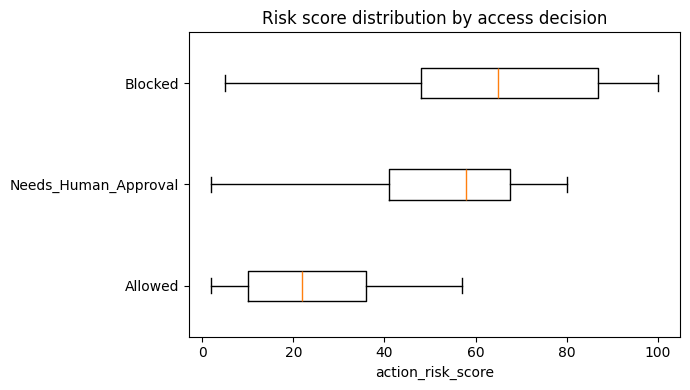

In [20]:
# --- 6.4 Why the score alone can't decide: score distribution by decision ---
# If the decision classes overlap on the score axis, no single threshold separates them.
order = df.groupby("access_decision")[TARGET].median().sort_values().index
data = [df.loc[df.access_decision == d, TARGET] for d in order]
plt.figure(figsize=(7, 4))
plt.boxplot(data, vert=False)
plt.yticks(range(1, len(order) + 1), list(order))
plt.xlabel("action_risk_score")
plt.title("Risk score distribution by access decision")
plt.tight_layout(); plt.show()

In [21]:
# --- 6.5 Part B revisited: score ALONE vs score + a few key signals ---
# The score-only model couldn't predict 'Needs_Human_Approval' at all. Does adding a
# few features recover that middle tier? This quantifies exactly what routing to a
# human requires beyond the score (supports 'match oversight to autonomy').
from sklearn.metrics import accuracy_score, f1_score
extra = [c for c in ["permission_match", "prompt_injection_detected", "data_exfiltration_risk"]
         if c in df.columns]
Xb = df[[TARGET] + extra].values
yb = df["access_decision"]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25,
                                              random_state=RANDOM_STATE, stratify=yb)
clf_plus = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xb_tr, yb_tr)
pred_plus = clf_plus.predict(Xb_te)
print(f"Features used: action_risk_score + {extra}\n")
print(classification_report(yb_te, pred_plus, zero_division=0))
print(f"Score + {len(extra)} features -> accuracy {accuracy_score(yb_te, pred_plus):.3f}, "
      f"macro-F1 {f1_score(yb_te, pred_plus, average='macro', zero_division=0):.3f}")
print("Watch the Needs_Human_Approval row vs the score-only version above.")

Features used: action_risk_score + ['permission_match', 'prompt_injection_detected', 'data_exfiltration_risk']

                      precision    recall  f1-score   support

             Allowed       0.96      0.76      0.85       131
             Blocked       1.00      0.95      0.97       359
Needs_Human_Approval       0.53      0.92      0.67        60

            accuracy                           0.90       550
           macro avg       0.83      0.88      0.83       550
        weighted avg       0.94      0.90      0.91       550

Score + 3 features -> accuracy 0.902, macro-F1 0.830
Watch the Needs_Human_Approval row vs the score-only version above.


In [22]:
# --- 6.6 Profile the over-blocked cases (Blocked despite a low score) ---
over_blocked = df[(df.access_decision == "Blocked") & (df[TARGET] <= 30)]
print(f"Over-blocked cases (Blocked despite score <= 30): {len(over_blocked)}\n")
for col in ["requested_action", "resource_type", "user_role", "agent_role"]:
    if col in over_blocked.columns:
        print(f"{col}:")
        print(over_blocked[col].value_counts().head(5).to_string(), "\n")

Over-blocked cases (Blocked despite score <= 30): 98

requested_action:
requested_action
read_record       43
search_records    34
create_ticket     18
send_email         2
download_file      1 

resource_type:
resource_type
public_knowledge_base    55
support_ticket           30
customer_profile          4
sales_pipeline            4
invoice                   3 

user_role:
user_role
analyst       29
employee      26
manager       10
contractor     8
admin          7 

agent_role:
agent_role
finance_reconciliation_agent    19
security_monitoring_agent       12
customer_support_agent          12
data_analytics_agent             9
it_helpdesk_agent                9 



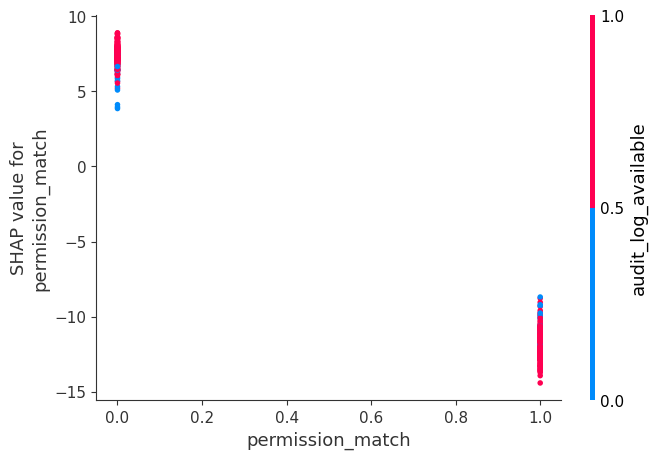

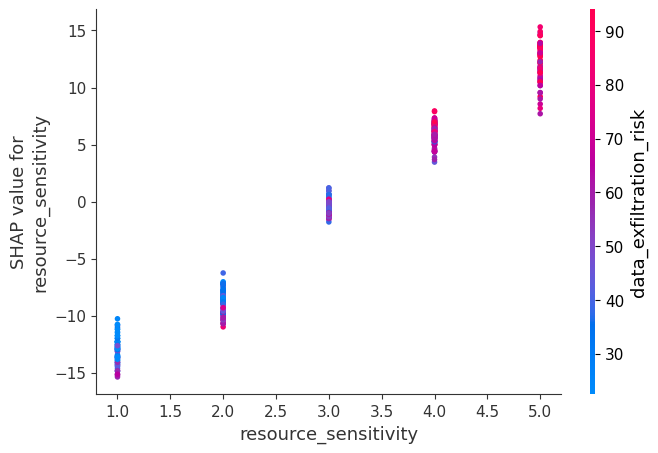

In [23]:
# --- 6.7 SHAP dependence: HOW the score responds to its top drivers ---
# Importance tells us WHICH features matter; dependence plots show the SHAPE of the
# effect (e.g. does risk jump when permission_match flips 1 -> 0?).
for feat in ["permission_match", "resource_sensitivity"]:
    if feat in X_test.columns:
        shap.dependence_plot(feat, shap_values, X_test, show=True)

In [24]:
# --- 6.8 Save key metrics to disk for the report / poster ---
import json
metrics = {
    "n_rows": int(len(df)),
    "n_features": int(X.shape[1]),
    "xgb_test_r2": round(float(r2_score(y_test, xgb_model.predict(X_test))), 3),
    "xgb_test_mae": round(float(mean_absolute_error(y_test, xgb_model.predict(X_test))), 2),
    "xgb_cv_r2_mean": round(float(cv_xgb.mean()), 3),
    "xgb_cv_r2_std": round(float(cv_xgb.std()), 3),
    "named_factors_r2": round(float(r2_named), 3),
    "model4_accuracy": round(float(acc_full), 3),
    "score_only_accuracy": round(float(acc_so), 3),
    "over_blocked_count": int(len(over_blocked)),
}
with open("results_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved results_metrics.json:")
print(json.dumps(metrics, indent=2))

Saved results_metrics.json:
{
  "n_rows": 2200,
  "n_features": 67,
  "xgb_test_r2": 0.937,
  "xgb_test_mae": 5.45,
  "xgb_cv_r2_mean": 0.936,
  "xgb_cv_r2_std": 0.004,
  "named_factors_r2": 0.481,
  "model4_accuracy": 0.953,
  "score_only_accuracy": 0.758,
  "over_blocked_count": 98
}


## Triangulated findings

Run all cells, then read across the models:

1. **Drivers (Model 1):** the SHAP ranking is the ground truth for what the score responds to.
2. **Coherence (Model 2):** compare the tree's split variables with SHAP's top drivers — agreement means the scoring logic is simple and consistent; disagreement means interactions the rules miss.
3. **Blind spots (Model 3):** anomalous-but-low-scored rows above are candidates for scoring-policy gaps — review them manually.
4. **Decision consistency (Model 4):** the contradiction tables show where enforcement diverges from the score; each `Allowed`-with-high-score row is a potential security exception worth auditing.
5. **Direct answer (Section 5):** Part A's R² answers *can we predict the score?*; Part B's score-only accuracy answers *can the score decide access?* Read the two printed verdicts together for the bottom line on the research question.

## Findings & conclusions

*Results below are from this run: 2,200 requests, 67 one-hot features.*

### Answer to the research question

**Part 1 — Can we predict the risk score from autonomy, permissions, tools, and resource access?**
Partially. Those four named factors *alone* explain R² ≈ 0.48 of the score. The full
feature set reaches R² ≈ 0.94 (MAE ≈ 5.4 pts; 5-fold CV 0.936 ± 0.004), but the extra
power comes from **threat-detection signals the question doesn't name** —
`prompt_injection_detected`, `data_exfiltration_risk`, and `previous_failed_attempts`.
So the score is highly predictable, just not primarily from the four factors asked about.

**Part 2 — Can the score decide whether access is granted?**
Only for the clear-cut cases. Using the score alone, a classifier predicts
`access_decision` at 76% accuracy but **never** identifies the `Needs_Human_Approval`
tier (F1 = 0.00) — those requests sit at mid-range scores that overlap both neighbours.
Adding three signals (permission match + prompt injection + exfiltration risk) recovers
that tier: accuracy 90%, macro-F1 0.51 → 0.83, human-approval recall 0 → 0.92.
**The score can gate allow-vs-block, but deciding what needs a human requires more than the score.**

### Key findings

- **The scoring logic is simple / near-linear.** A plain linear model reaches R² ≈ 0.92
  vs XGBoost's 0.94, and the depth-3 tree splits on the same variables SHAP ranks highest
  (`permission_match`, `resource_sensitivity`, `data_exfiltration_risk`). The system
  behaves like a transparent weighted sum, not an opaque black box.
- **Top drivers:** permission mismatch and resource sensitivity dominate, followed by
  specific actions (`read_record`, `search_records`) and the threat signals.
- **No dangerous leniency, but notable over-blocking.** Zero requests were Allowed with a
  high score (≥ 70); 98 were Blocked despite a low score (≤ 30). Those over-blocks are
  overwhelmingly benign reads (`read_record`, `search_records`) on the *least* sensitive
  resources (`public_knowledge_base`, `support_ticket`) — unnecessary friction on low-risk activity.
- **Few blind spots.** Only 4 anomalous requests received a low score, so the score rarely
  under-rates unusual activity.
- **No secondary leakage.** The threat signals correlate only moderately with the score
  (0.22–0.55), and removing them drops R² by just ~0.06 — they are legitimate inputs, not
  the score relabelled.

### Limitations

- **Label subjectivity.** The score and decisions were assigned by a prior process; the
  models learn *that* definition of risk, not ground truth. Conclusions may not transfer to
  organisations with different security policies or risk appetites.
- **Rare high-risk actions are under-represented.** Genuine agentic misalignment is scarce
  in the data, so performance on the most dangerous cases is the least certain — the metric
  that matters most is the hardest to trust here.
- **Simulated, single-source data.** Results come from one synthetic Kaggle dataset; a real
  deployment would need revalidation before any operational use.

### Future Additions to be added on at a later date

- **Route the middle tier with more than the score.** Flag `Needs_Human_Approval` using
  score + permission-match + threat signals, matching oversight to autonomy.
- **Audit the over-blocking.** Review the 98 low-score blocks on public / low-sensitivity
  resources to cut needless friction without lowering security.
- **Monitor for drift.** Re-run the blind-spot and contradiction checks on fresh logs; a
  rising "Allowed-despite-high-score" count would be an early warning sign.